In [1]:
# Shared setup: clone/refresh the repo, switch to the demo branch, mount Drive, and install dependencies.
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

BRANCH_NAME = 'main'
repo_dir = Path('/content/KVCompass')
if not repo_dir.exists():
    !git clone https://github.com/AarnavSawant/KVCompass.git /content/KVCompass

%cd /content/KVCompass
!git fetch origin
!git checkout "$BRANCH_NAME"
!git pull origin "$BRANCH_NAME"
!nvidia-smi
!python -m pip install --upgrade pip
!pip install -r requirements.txt
!pip install -e .


Mounted at /content/drive
Cloning into '/content/KVCompass'...
remote: Enumerating objects: 267, done.
remote: Counting objects: 100% (267/267), done.
remote: Compressing objects: 100% (170/170), done.
remote: Total 267 (delta 125), reused 214 (delta 81), pack-reused 0 (from 0)
Receiving objects: 100% (267/267), 1.39 MiB | 4.58 MiB/s, done.
Resolving deltas: 100% (125/125), done.
/content/KVCompass
Already on 'main'
Your branch is up to date with 'origin/main'.
From https://github.com/AarnavSawant/KVCompass
 * branch            main       -> FETCH_HEAD
Already up to date.
Wed Apr 29 23:08:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf   

In [2]:

# Shared values used by all run cells.
from pathlib import Path

SHARED_RESULTS_DIR = Path('/content/drive/MyDrive/KVCompass')
SHARED_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print('Shared results dir:', SHARED_RESULTS_DIR)

Shared results dir: /content/drive/MyDrive/KVCompass


In [3]:
# Load and combine the benchmark assignment summaries.
import json
from pathlib import Path
import pandas as pd

summary_root = SHARED_RESULTS_DIR / 'benchmark_eval'
summary_paths = [summary_root / f'assignment_{i}__summary.csv' for i in range(1, 6) if (summary_root / f'assignment_{i}__summary.csv').exists()]
combined_summary = pd.concat([pd.read_csv(path) for path in summary_paths], ignore_index=True) if summary_paths else pd.DataFrame()
print('Summary files:', [str(path) for path in summary_paths])
display(combined_summary)

if not combined_summary.empty:
    rows = []
    for _, row in combined_summary.iterrows():
        metrics = json.loads(Path(row['metrics_path']).read_text())
        metric_values = []
        for task_metrics in metrics.values():
            if isinstance(task_metrics, dict):
                metric_values.extend(v for v in task_metrics.values() if isinstance(v, (int, float)))
        rows.append({
            'scenario_name': row['scenario_name'],
            'dataset': row['dataset'],
            'data_dir': row['data_dir'],
            'task_prefixes': row['task_prefixes'],
            'method': row['method'],
            'budget': row['budget'],
            'avg_quality': round(sum(metric_values) / len(metric_values), 2) if metric_values else None,
            'avg_latency_seconds': row.get('avg_latency_seconds'),
            'avg_throughput_tokens_per_second': row.get('avg_throughput_tokens_per_second'),
            'peak_gpu_memory_mb': row.get('peak_gpu_memory_mb'),
        })
    leaderboard = pd.DataFrame(rows).sort_values(['scenario_name', 'avg_quality', 'avg_latency_seconds'], ascending=[True, False, True])
    display(leaderboard)
else:
    print('No assignment summaries found yet.')


Summary files: ['/content/drive/MyDrive/KVCompass/benchmark_eval/assignment_1__summary.csv', '/content/drive/MyDrive/KVCompass/benchmark_eval/assignment_2__summary.csv', '/content/drive/MyDrive/KVCompass/benchmark_eval/assignment_3__summary.csv', '/content/drive/MyDrive/KVCompass/benchmark_eval/assignment_4__summary.csv', '/content/drive/MyDrive/KVCompass/benchmark_eval/assignment_5__summary.csv']


,scenario_name,dataset,data_dir,task_prefixes,model,method,budget,predictions_path,metrics_path,avg_latency_seconds,avg_throughput_tokens_per_second,peak_gpu_memory_mb
0,needle_in_a_haystack_4k,ruler,4096,niah,Qwen/Qwen3-8B,snapkv,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,3.420993,15.018375,16398.09033
1,needle_in_a_haystack_4k,ruler,4096,niah,Qwen/Qwen3-8B,expected_attention,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,2.619632,12.868609,16398.69775
2,needle_in_a_haystack_4k,ruler,4096,niah,Qwen/Qwen3-8B,knorm,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,2.416859,14.028300,16397.60596
3,needle_in_a_haystack_4k,ruler,4096,niah,Qwen/Qwen3-8B,tova,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,2.613547,13.723594,16397.60596
4,needle_in_a_haystack_4k,ruler,4096,niah,Qwen/Qwen3-8B,streaming_llm,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,3.066988,14.660233,16397.60596
...,...,...,...,...,...,...,...,...,...,...,...,...
67,aggregation_16k,ruler,16384,"cwe,fwe",Qwen/Qwen3-8B,snapkv,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,5.161916,9.431863,19491.30420
68,aggregation_16k,ruler,16384,"cwe,fwe",Qwen/Qwen3-8B,expected_attention,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,6.136360,9.908813,19491.30420
69,aggregation_16k,ruler,16384,"cwe,fwe",Qwen/Qwen3-8B,knorm,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,4.857968,9.589446,19491.30420
70,aggregation_16k,ruler,16384,"cwe,fwe",Qwen/Qwen3-8B,tova,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,4.923134,9.287782,19491.30420


,scenario_name,dataset,data_dir,task_prefixes,method,budget,avg_quality,avg_latency_seconds,avg_throughput_tokens_per_second,peak_gpu_memory_mb
70,aggregation_16k,ruler,16384,"cwe,fwe",tova,0.5,87.91,4.923134,9.287782,19491.30420
67,aggregation_16k,ruler,16384,"cwe,fwe",snapkv,0.5,83.85,5.161916,9.431863,19491.30420
71,aggregation_16k,ruler,16384,"cwe,fwe",streaming_llm,0.5,81.66,5.934074,10.467635,19491.30420
69,aggregation_16k,ruler,16384,"cwe,fwe",knorm,0.5,80.33,4.857968,9.589446,19491.30420
68,aggregation_16k,ruler,16384,"cwe,fwe",expected_attention,0.5,62.28,6.136360,9.908813,19491.30420
...,...,...,...,...,...,...,...,...,...,...
24,question_answering_8k,ruler,8192,qa,streaming_llm,0.5,38.12,1.137030,5.964796,17113.69775
22,question_answering_8k,ruler,8192,qa,knorm,0.5,34.59,1.448062,8.717564,17113.69775
55,vt_16k_baseline,ruler,16384,vt,no_compression,1.0,100.00,2.578023,6.117942,19586.41357
49,vt_4k_baseline,ruler,4096,vt,no_compression,1.0,100.00,1.190860,13.117454,16563.62988


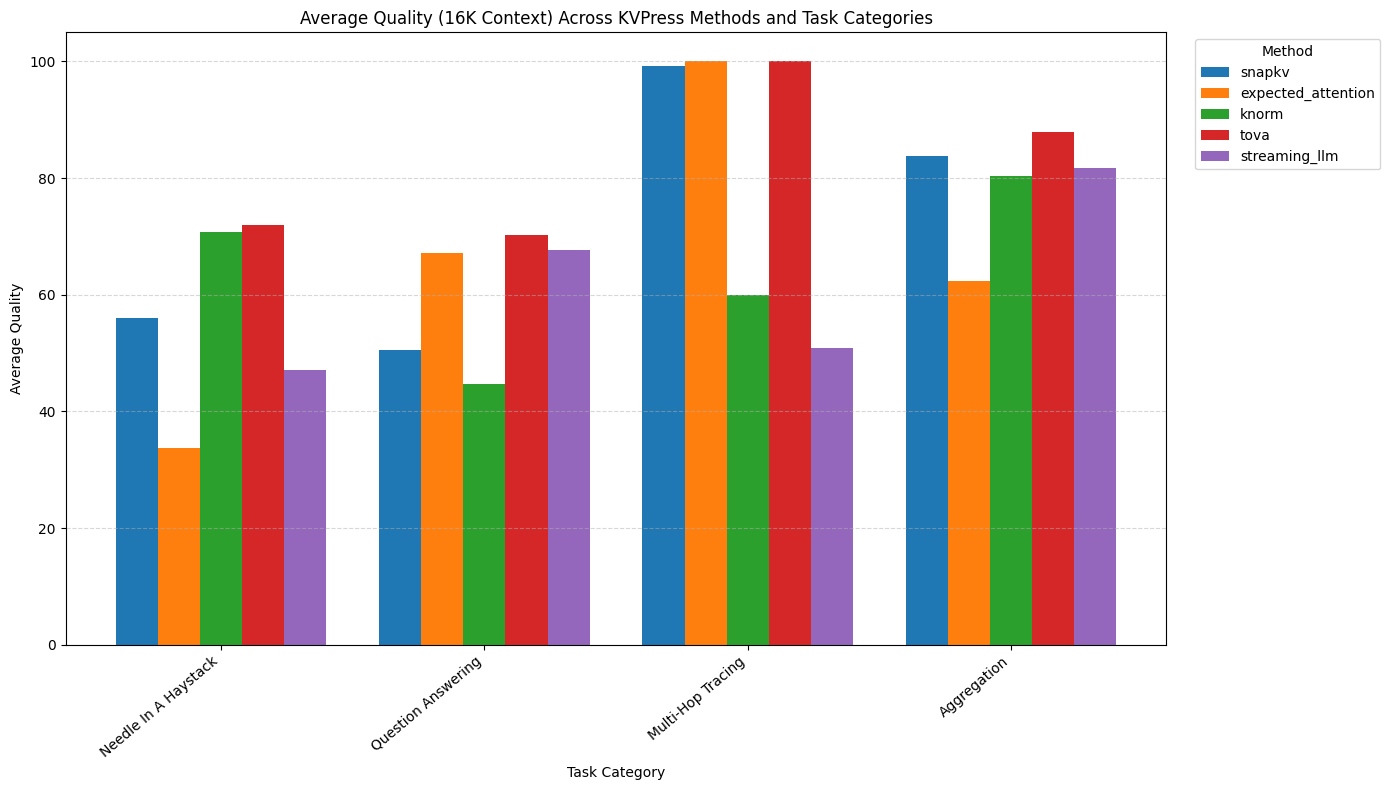

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- robust mapping from scenario_name -> task category ----
mapping = {
    "needle_in_a_haystack": "Needle In A Haystack",
    "qa": "Question Answering",
    "question_answering": "Question Answering",
    "multi_hop": "Multi-Hop Tracing",
    "multihop": "Multi-Hop Tracing",
    "aggregation": "Aggregation",
    "agg": "Aggregation"
}

def map_task_category(name):
    name = str(name).lower()
    for key, val in mapping.items():
        if key in name:
            return val
    return "Other"

# ---- copy and preprocess ----
plot_df = leaderboard.copy()
plot_df["task_category"] = plot_df["scenario_name"].apply(map_task_category)

# DEBUG (optional: uncomment if still issues)
# print(plot_df["scenario_name"].unique())

# ---- filter to 16K context ----
plot_df = plot_df[plot_df["data_dir"] == 16384].copy()

# ---- aggregate avg_quality ----
plot_df = (
    plot_df.groupby(["task_category", "method"])["avg_quality"]
    .mean()
    .unstack()
)

# ---- enforce order ----
task_order = [
    "Needle In A Haystack",
    "Question Answering",
    "Multi-Hop Tracing",
    "Aggregation"
]
method_order = ["snapkv", "expected_attention", "knorm", "tova", "streaming_llm"]

plot_df = plot_df.reindex(task_order)
plot_df = plot_df.reindex(columns=[m for m in method_order if m in plot_df.columns])

# ---- plot ----
x = np.arange(len(plot_df.index))
n_methods = len(plot_df.columns)
width = 0.8 / max(n_methods, 1)

fig, ax = plt.subplots(figsize=(14, 8))

for i, method in enumerate(plot_df.columns):
    ax.bar(
        x + (i - (n_methods - 1) / 2) * width,
        plot_df[method].values,
        width=width,
        label=method
    )

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=40, ha="right")
ax.set_ylabel("Average Quality")
ax.set_xlabel("Task Category")
ax.set_title("Average Quality (16K Context) Across KVPress Methods and Task Categories")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

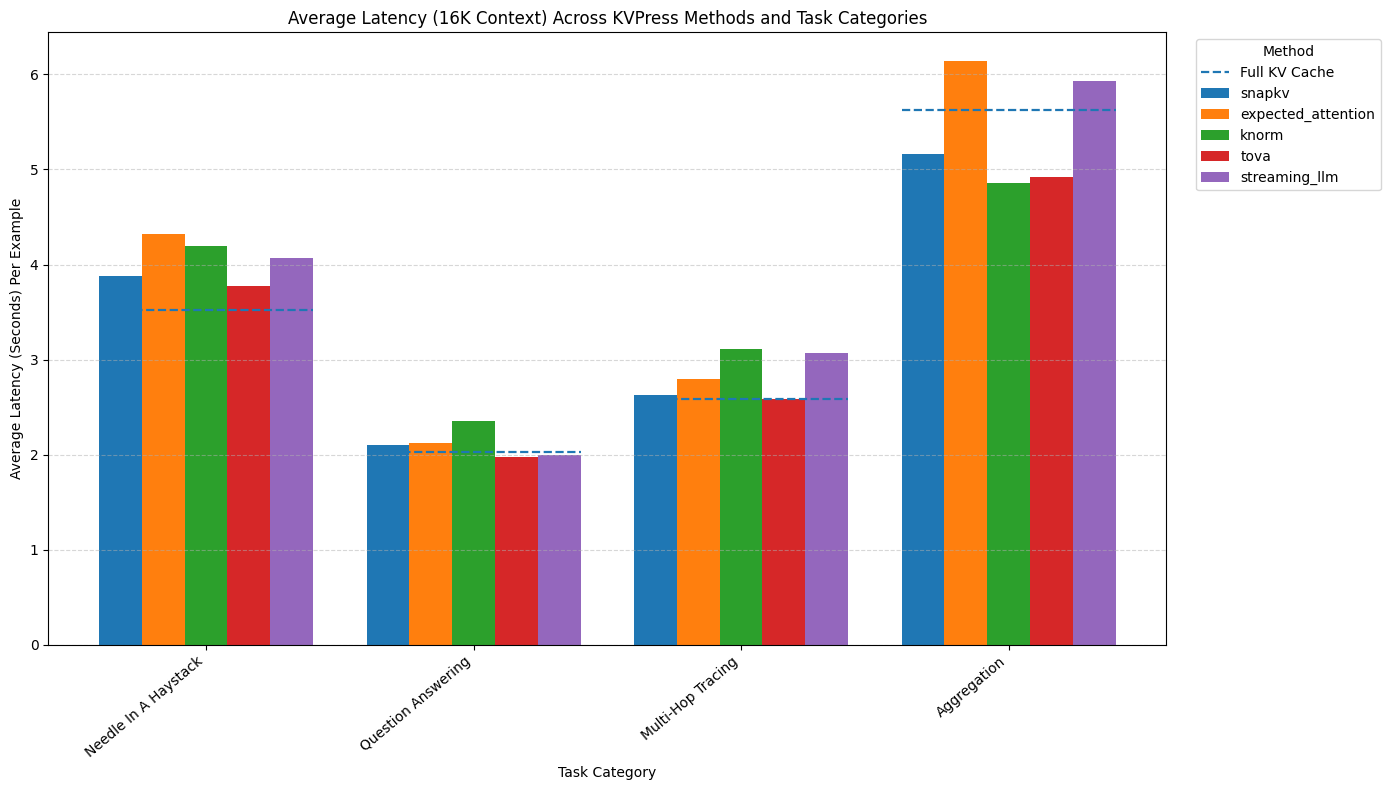

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- robust mapping from scenario_name -> task category ----
mapping = {
    "needle_in_a_haystack": "Needle In A Haystack",
    "qa": "Question Answering",
    "question_answering": "Question Answering",
    "multi_hop": "Multi-Hop Tracing",
    "multihop": "Multi-Hop Tracing",
    "aggregation": "Aggregation",
    "agg": "Aggregation"
}

def map_task_category(name):
    name = str(name).lower()
    for key, val in mapping.items():
        if key in name:
            return val
    return "Other"

# ---- copy and preprocess ----
plot_df = leaderboard.copy()
plot_df["task_category"] = plot_df["scenario_name"].apply(map_task_category)

# ---- filter to 16K context ----
plot_df = plot_df[plot_df["data_dir"] == 16384].copy()

# ---- average latency by task category and method ----
latency_df = (
    plot_df.groupby(["task_category", "method"])["avg_latency_seconds"]
    .mean()
    .unstack()
)

# ---- enforce order ----
task_order = [
    "Needle In A Haystack",
    "Question Answering",
    "Multi-Hop Tracing",
    "Aggregation"
]
method_order = ["snapkv", "expected_attention", "knorm", "tova", "streaming_llm"]

latency_df = latency_df.reindex(task_order)
latency_df = latency_df.reindex(columns=[m for m in method_order if m in latency_df.columns])

# ---- full KV cache baseline values (edit if you want different numbers) ----
full_kv_cache = {
    "Needle In A Haystack": 3.52,
    "Question Answering": 2.03,
    "Multi-Hop Tracing": 2.58,
    "Aggregation": 5.63
}
baseline_df = pd.Series(full_kv_cache).reindex(task_order)

# ---- plot ----
x = np.arange(len(latency_df.index))
n_methods = len(latency_df.columns)
width = 0.8 / max(n_methods, 1)

fig, ax = plt.subplots(figsize=(14, 8))

for i, method in enumerate(latency_df.columns):
    ax.bar(
        x + (i - (n_methods - 1) / 2) * width,
        latency_df[method].values,
        width=width,
        label=method
    )

# dashed baseline lines
for i, task in enumerate(latency_df.index):
    y = baseline_df.loc[task]
    if pd.notna(y):
        ax.hlines(
            y=y,
            xmin=i - 0.4,
            xmax=i + 0.4,
            linestyles="--",
            linewidth=1.6,
            label="Full KV Cache" if i == 0 else None
        )

ax.set_xticks(x)
ax.set_xticklabels(latency_df.index, rotation=40, ha="right")
ax.set_ylabel("Average Latency (Seconds) Per Example")
ax.set_xlabel("Task Category")
ax.set_title("Average Latency (16K Context) Across KVPress Methods and Task Categories")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

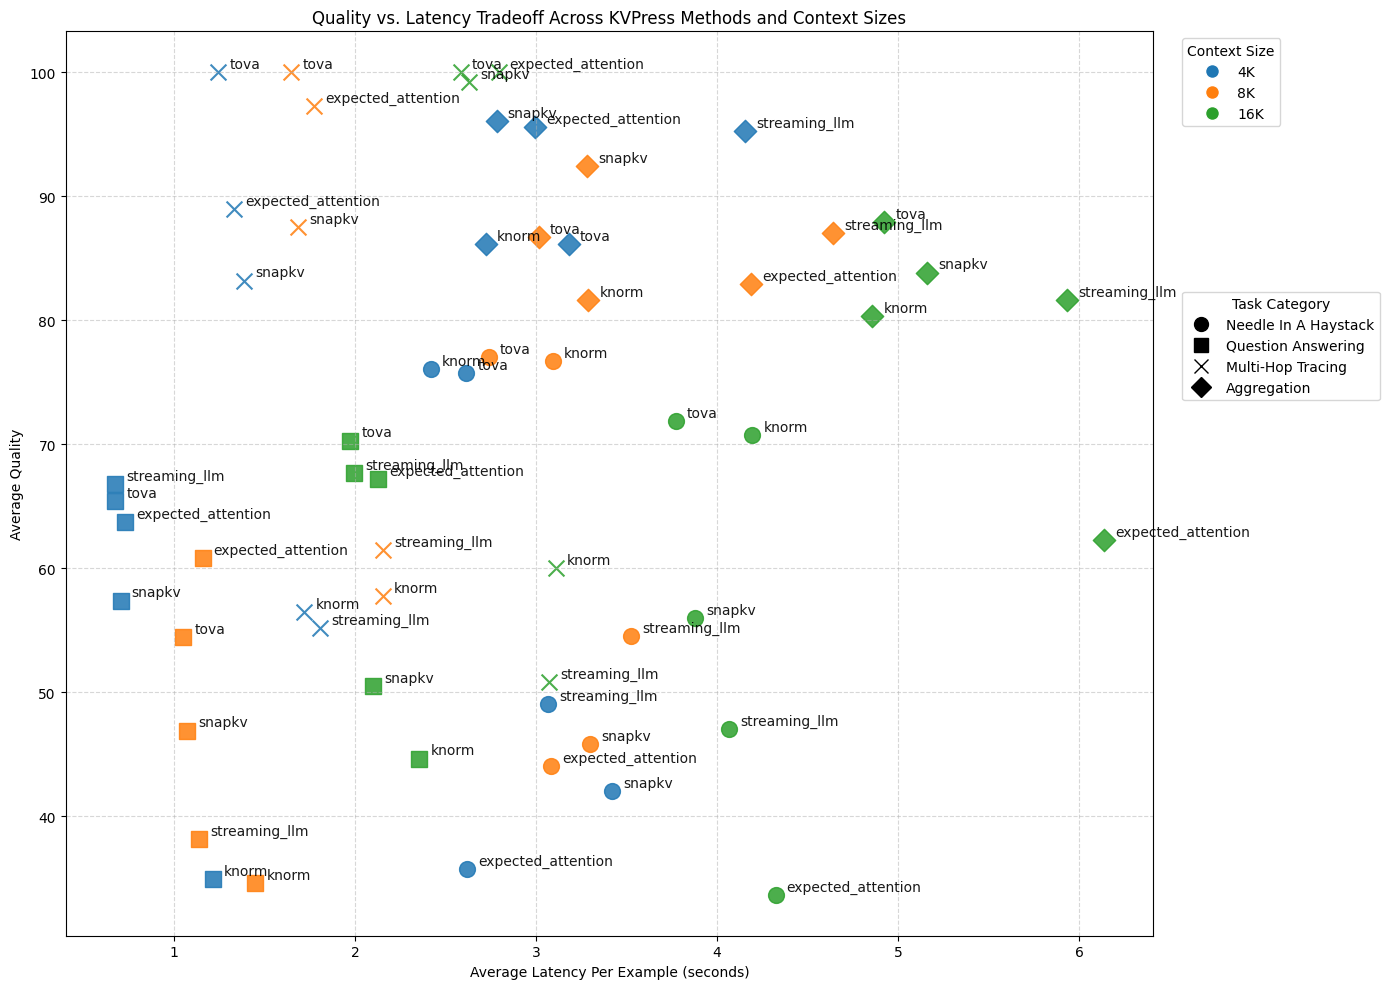

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# ---- map scenario_name -> task category ----
def map_task_category(name):
    name = str(name).lower()
    if "needle_in_a_haystack" in name:
        return "Needle In A Haystack"
    elif "question" in name or "qa" in name:
        return "Question Answering"
    elif "multi" in name and "hop" in name:
        return "Multi-Hop Tracing"
    elif "aggregation" in name or "agg" in name:
        return "Aggregation"
    return "Other"

# ---- map context size ----
def map_context_label(x):
    x = int(x)
    if x == 4096:
        return "4K"
    elif x == 8192:
        return "8K"
    elif x == 16384:
        return "16K"
    return str(x)

# ---- prepare dataframe ----
plot_df = leaderboard.copy()
plot_df["task_category"] = plot_df["scenario_name"].apply(map_task_category)
plot_df["context_label"] = plot_df["data_dir"].apply(map_context_label)

# ---- REMOVE no_compression / baseline methods ----
exclude_methods = ["no_compression", "full", "full_kv_cache", "baseline"]
plot_df = plot_df[~plot_df["method"].str.lower().isin(exclude_methods)]

# ---- keep only relevant tasks ----
task_order = [
    "Needle In A Haystack",
    "Question Answering",
    "Multi-Hop Tracing",
    "Aggregation"
]
plot_df = plot_df[plot_df["task_category"].isin(task_order)].copy()

# ---- aggregate ----
plot_df = (
    plot_df.groupby(["task_category", "context_label", "method"], as_index=False)
    .agg({
        "avg_quality": "mean",
        "avg_latency_seconds": "mean"
    })
)

# ---- visual encodings ----
context_colors = {
    "4K": "tab:blue",
    "8K": "tab:orange",
    "16K": "tab:green"
}

task_markers = {
    "Needle In A Haystack": "o",
    "Question Answering": "s",
    "Multi-Hop Tracing": "x",
    "Aggregation": "D"
}

# ---- plot ----
fig, ax = plt.subplots(figsize=(14, 10))

for _, row in plot_df.iterrows():
    ax.scatter(
        row["avg_latency_seconds"],
        row["avg_quality"],
        color=context_colors.get(row["context_label"], "gray"),
        marker=task_markers.get(row["task_category"], "o"),
        s=130,
        alpha=0.85
    )
    ax.annotate(
        row["method"],
        (row["avg_latency_seconds"], row["avg_quality"]),
        xytext=(8, 3),
        textcoords="offset points",
        fontsize=10,
        alpha=0.9
    )

# ---- legends ----
context_handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=color, markersize=10, label=ctx)
    for ctx, color in context_colors.items()
]

task_handles = [
    plt.Line2D([0], [0], marker=marker, color='black',
               linestyle='None', markersize=10, label=task)
    for task, marker in task_markers.items()
]

legend1 = ax.legend(handles=context_handles, title="Context Size", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.add_artist(legend1)
ax.legend(handles=task_handles, title="Task Category", loc="upper left", bbox_to_anchor=(1.02, 0.72))

# ---- labels ----
ax.set_xlabel("Average Latency Per Example (seconds)")
ax.set_ylabel("Average Quality")
ax.set_title("Quality vs. Latency Tradeoff Across KVPress Methods and Context Sizes")
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()